In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# 1. Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [4]:
# 2. Xây dựng lớp Dataset tùy chỉnh
class LocalMNIST(Dataset):
    def __init__(self, image_path, label_path, transform=None):
        self.transform = transform
        self.images = self.read_images(image_path)
        self.labels = self.read_labels(label_path)

    def read_images(self, path):
        with open(path, 'rb') as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.fromfile(f, dtype=np.uint8).reshape(num, 28, 28)
        return images

    def read_labels(self, path):
        with open(path, 'rb') as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.fromfile(f, dtype=np.uint8)
        return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
# 3. Chuẩn bị dữ liệu và Augmentation
transform_train = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ElasticTransform(alpha=50.0, sigma=5.0),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_img_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/train-images.idx3-ubyte'
train_lbl_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/train-labels.idx1-ubyte'
test_img_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/t10k-images.idx3-ubyte'
test_lbl_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/t10k-labels.idx1-ubyte'

train_dataset = LocalMNIST(train_img_path, train_lbl_path, transform=transform_train)
test_dataset = LocalMNIST(test_img_path, test_lbl_path, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [7]:
# 4. Định nghĩa mạng CNN LeNet5
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # Block 1: Input (1, 28, 28) -> Output (6, 24, 24) -> Pool (6, 12, 12)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Input (6, 12, 12) -> Output (16, 8, 8) -> Pool (16, 4, 4)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block Fully Connected
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

        # Thêm Dropout nhẹ để tránh overfitting
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Trích xuất đặc trưng không gian 2D
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        # Duỗi phẳng (Flatten) để đưa vào mạng FC
        x = x.view(-1, 16 * 4 * 4)

        # Phân loại
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [8]:
model = LeNet5(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Lưu trữ Metrics
train_losses = []
train_accuracies = []

epochs = 25
print("\nBắt đầu quá trình huấn luyện...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train

    # Lưu lại lịch sử để vẽ biểu đồ
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # In ra kết quả từng epoch
    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}%")

print("\nHoàn thành huấn luyện!")


Bắt đầu quá trình huấn luyện...
Epoch [01/25] | Train Loss: 0.6335 - Train Acc: 79.52%
Epoch [02/25] | Train Loss: 0.2286 - Train Acc: 93.02%
Epoch [03/25] | Train Loss: 0.1759 - Train Acc: 94.69%
Epoch [04/25] | Train Loss: 0.1479 - Train Acc: 95.49%
Epoch [05/25] | Train Loss: 0.1325 - Train Acc: 96.04%
Epoch [06/25] | Train Loss: 0.1181 - Train Acc: 96.42%
Epoch [07/25] | Train Loss: 0.1118 - Train Acc: 96.61%
Epoch [08/25] | Train Loss: 0.1050 - Train Acc: 96.85%
Epoch [09/25] | Train Loss: 0.1010 - Train Acc: 97.02%
Epoch [10/25] | Train Loss: 0.1003 - Train Acc: 96.96%
Epoch [11/25] | Train Loss: 0.0932 - Train Acc: 97.17%
Epoch [12/25] | Train Loss: 0.0946 - Train Acc: 97.16%
Epoch [13/25] | Train Loss: 0.0909 - Train Acc: 97.31%
Epoch [14/25] | Train Loss: 0.0850 - Train Acc: 97.46%
Epoch [15/25] | Train Loss: 0.0864 - Train Acc: 97.48%
Epoch [16/25] | Train Loss: 0.0819 - Train Acc: 97.58%
Epoch [17/25] | Train Loss: 0.0809 - Train Acc: 97.53%
Epoch [18/25] | Train Loss: 0.07

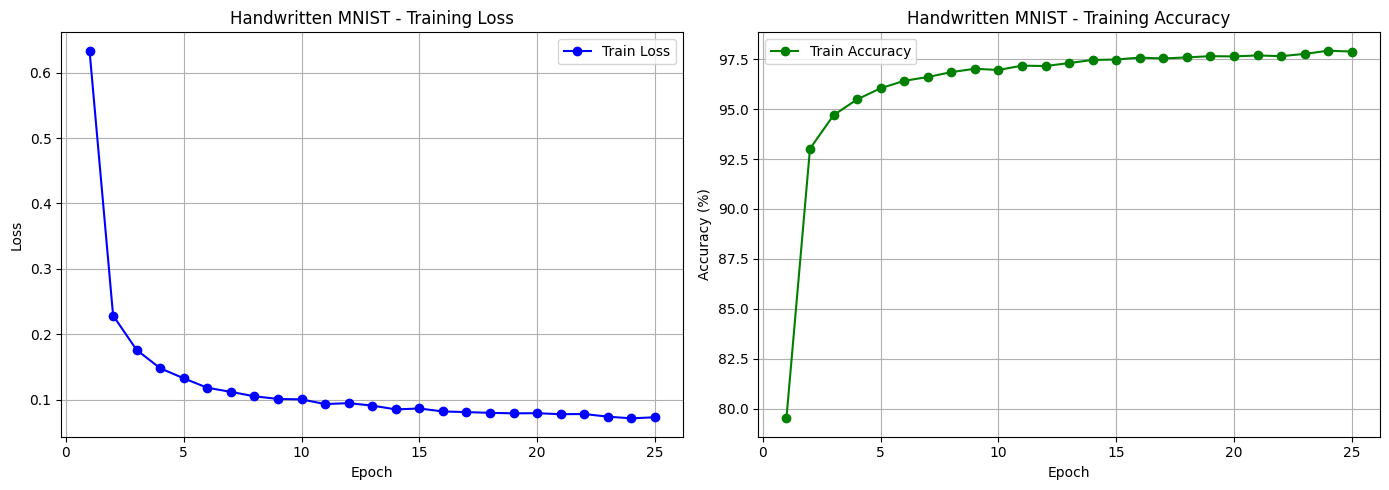

In [10]:
# 6. Visualization
plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='blue', marker='o')
plt.title('Handwritten MNIST - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy', color='green', marker='o')
plt.title('Handwritten MNIST - Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# 7. Đánh giá Độc lập trên tập Test
print("\n--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
model.eval()
test_running_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_loss = test_running_loss / total_test
final_acc = 100 * correct_test / total_test

print(f"Kết quả kiểm thử:")
print(f" > Test Loss: {final_loss:.4f}")
print(f" > Test Accuracy: {final_acc:.2f}%")


--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
Kết quả kiểm thử:
 > Test Loss: 0.0206
 > Test Accuracy: 99.33%
